## hallo 

In [620]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

In [621]:
data_transit = "/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/raw_data/transit_stations.csv"

df_transit = pd.read_csv(data_transit)

df_transit

,station_name,line,lat,lon,year_opened,to_brandenburg_gate_km
0,Warschauer Straße,U1,52.5057,13.4495,1902,5.00
1,Schlesisches Tor,U1,52.5012,13.4423,1902,4.68
2,Görlitzer Bahnhof,U1,52.4986,13.4286,1902,3.97
3,Kottbusser Tor,U1,52.4994,13.4181,1902,3.32
4,Prinzenstraße,U1,52.5006,13.4097,1902,2.78
...,...,...,...,...,...,...
130,Charlottenburg S,Stadtbahn,52.5060,13.3030,1882,5.18
131,Savignyplatz,Stadtbahn,52.5050,13.3208,1882,4.05
132,Zoologischer Garten S,Stadtbahn,52.5071,13.3320,1882,3.26
133,Tiergarten S,Stadtbahn,52.5145,13.3501,1882,1.88


In [622]:
data_sales = "/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/raw_data/secondary_sales.csv"

df_sales = pd.read_csv(data_sales)

df_sales

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,floor,total_floors,year_built,building_era,energy_class,position,condition,has_lift,has_balcony,has_cellar,has_parking,transit_station,transit_line,transit_distance_min,transit_distance_type,to_brandenburg_gate_km,price_eur,price_per_m2_eur,price_usd,price_per_m2_usd,mortgage_rate_at_listing
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2_room,2,69.0,1,6,2011,new_post_2010,B,hinterhaus,saniert,True,True,False,False,Gleisdreieck,U1,10,tram_bus,2.30,577000,8358,622867,9026,3.50
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3_room,3,82.0,4,5,2016,new_post_2010,B,vorderhaus,modernisiert,True,True,True,False,Wilmersdorfer Straße,U7,44,tram_bus,14.23,378000,4605,408004,4973,3.30
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1_room,1,28.3,2,4,1976,post_war_1949_1990,G,hinterhaus,modernisiert,False,False,True,True,Altstadt Spandau,U7,116,tram_bus,15.32,61000,2158,65916,2331,1.10
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4_room,4,108.0,3,5,1950,post_war_1949_1990,C,seitenflügel,modernisiert,False,False,True,False,Prinzenstraße,U1,11,tram_bus,2.54,711000,6582,767527,7109,3.50
4,S000005,2021-05-10,Wittenau,Reinickendorf,low,52.59374,13.31938,2_room,2,44.7,4,4,1884,altbau_pre_1949,E,seitenflügel,renovierungsbedürftig,False,False,True,False,Rosa-Luxemburg-Platz,U2,39,tram_bus,9.47,71000,1597,77078,1725,1.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,S049996,2022-09-17,Märkisches Viertel,Reinickendorf,low,52.60271,13.34964,1_room,1,47.1,2,4,1976,post_war_1949_1990,A,hinterhaus,saniert,True,True,False,True,Voltastraße,U8,35,tram_bus,9.79,129000,2737,139270,2956,3.40
49996,S049997,2023-06-18,Frohnau,Reinickendorf,medium,52.62787,13.29939,2_room,2,65.1,4,5,1942,altbau_pre_1949,G,vorderhaus,kernsaniert,False,True,True,True,Alexanderplatz S,Stadtbahn,64,tram_bus,13.49,216000,3312,232875,3577,3.85
49997,S049998,2023-03-12,Siemensstadt,Spandau,low,52.53700,13.24356,2_room,2,56.9,2,5,1982,post_war_1949_1990,C,vorderhaus,saniert,True,False,True,False,Siemensdamm,U7,11,walk,9.36,198000,3478,213628,3756,3.85
49998,S049999,2026-01-02,Malchow,Lichtenberg,low,52.56763,13.47799,3_room,3,84.4,2,5,1949,post_war_1949_1990,F,vorderhaus,renoviert,True,True,True,False,Alexanderplatz S,Stadtbahn,37,tram_bus,8.86,195000,2310,210673,2495,3.10


In [623]:
data_rentals = "/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/raw_data/rentals.csv"

df_rentals = pd.read_csv(data_rentals)

df_rentals['building_era'].count

<bound method Series.count of 0        post_war_1949_1990
1          modern_1990_2010
2          modern_1990_2010
3           altbau_pre_1949
4          modern_1990_2010
                ...        
29995         new_post_2010
29996       altbau_pre_1949
29997    post_war_1949_1990
29998       altbau_pre_1949
29999      modern_1990_2010
Name: building_era, Length: 30000, dtype: object>

In [624]:
data_new= "/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/raw_data/new_construction.csv"

df_new = pd.read_csv(data_new)

df_new.columns


Index(['id', 'date_listed', 'project_id', 'project_name', 'developer',
       'ortsteil', 'bezirk', 'lat', 'lon', 'property_type', 'rooms', 'area_m2',
       'floor', 'total_floors', 'energy_class', 'completion_year',
       'total_project_units', 'possession_status', 'payment_plan', 'has_lift',
       'has_balcony', 'has_parking', 'transit_station', 'transit_line',
       'transit_distance_min', 'to_brandenburg_gate_km', 'price_eur',
       'price_per_m2_eur', 'price_usd', 'price_per_m2_usd',
       'mortgage_rate_at_listing'],
      dtype='object')

In [625]:
data_monthly= "/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/raw_data/kiez_prices_monthly.csv"

df_monthly= pd.read_csv(data_monthly)

df_monthly

,year_month,ortsteil,bezirk,kiez_premium,secondary_price_per_m2_eur,new_construction_price_per_m2_eur,kaltmiete_per_m2_monthly_eur,secondary_price_per_m2_usd,n_listings_secondary,n_listings_new_construction,n_listings_rental,ecb_main_rate_pct,avg_mortgage_rate_pct
0,2020-01,Mitte (Ort),Mitte,high,7389,9312,20.53,7980,22,48,69,0.00,1.1
1,2020-02,Mitte (Ort),Mitte,high,7585,9571,21.07,8192,64,20,150,0.00,1.1
2,2020-03,Mitte (Ort),Mitte,high,7489,9737,19.24,8088,118,44,153,0.00,1.1
3,2020-04,Mitte (Ort),Mitte,high,7400,9376,19.24,7992,158,22,145,0.00,1.1
4,2020-05,Mitte (Ort),Mitte,high,7386,9112,19.21,7977,73,29,59,0.00,1.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6227,2025-12,Waidmannslust,Reinickendorf,low,4328,5479,12.98,4674,70,25,111,2.75,3.1
6228,2026-01,Waidmannslust,Reinickendorf,low,4432,5603,13.29,4787,30,15,161,2.75,3.1
6229,2026-02,Waidmannslust,Reinickendorf,low,4519,5633,13.55,4881,118,26,204,2.75,3.1
6230,2026-03,Waidmannslust,Reinickendorf,low,4344,5426,13.03,4692,20,16,21,2.75,3.1


## Analysis Sales Outliers & Missing Values

In [626]:
####Import
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr

In [627]:
df_sales.isnull().sum()                

id                          0
date_listed                 0
ortsteil                    0
bezirk                      0
kiez_premium                0
lat                         0
lon                         0
property_type               0
rooms                       0
area_m2                     0
floor                       0
total_floors                0
year_built                  0
building_era                0
energy_class                0
position                    0
condition                   0
has_lift                    0
has_balcony                 0
has_cellar                  0
has_parking                 0
transit_station             0
transit_line                0
transit_distance_min        0
transit_distance_type       0
to_brandenburg_gate_km      0
price_eur                   0
price_per_m2_eur            0
price_usd                   0
price_per_m2_usd            0
mortgage_rate_at_listing    0
dtype: int64

In [628]:
print(f" {df_sales.duplicated().sum()} duplicates")

 0 duplicates


In [629]:
target = 'price_eur' 
round(df_sales[target].describe(),0)

count      50000.0
mean      307538.0
std       248698.0
min        21000.0
25%       141000.0
50%       232000.0
75%       392000.0
max      3330000.0
Name: price_eur, dtype: float64

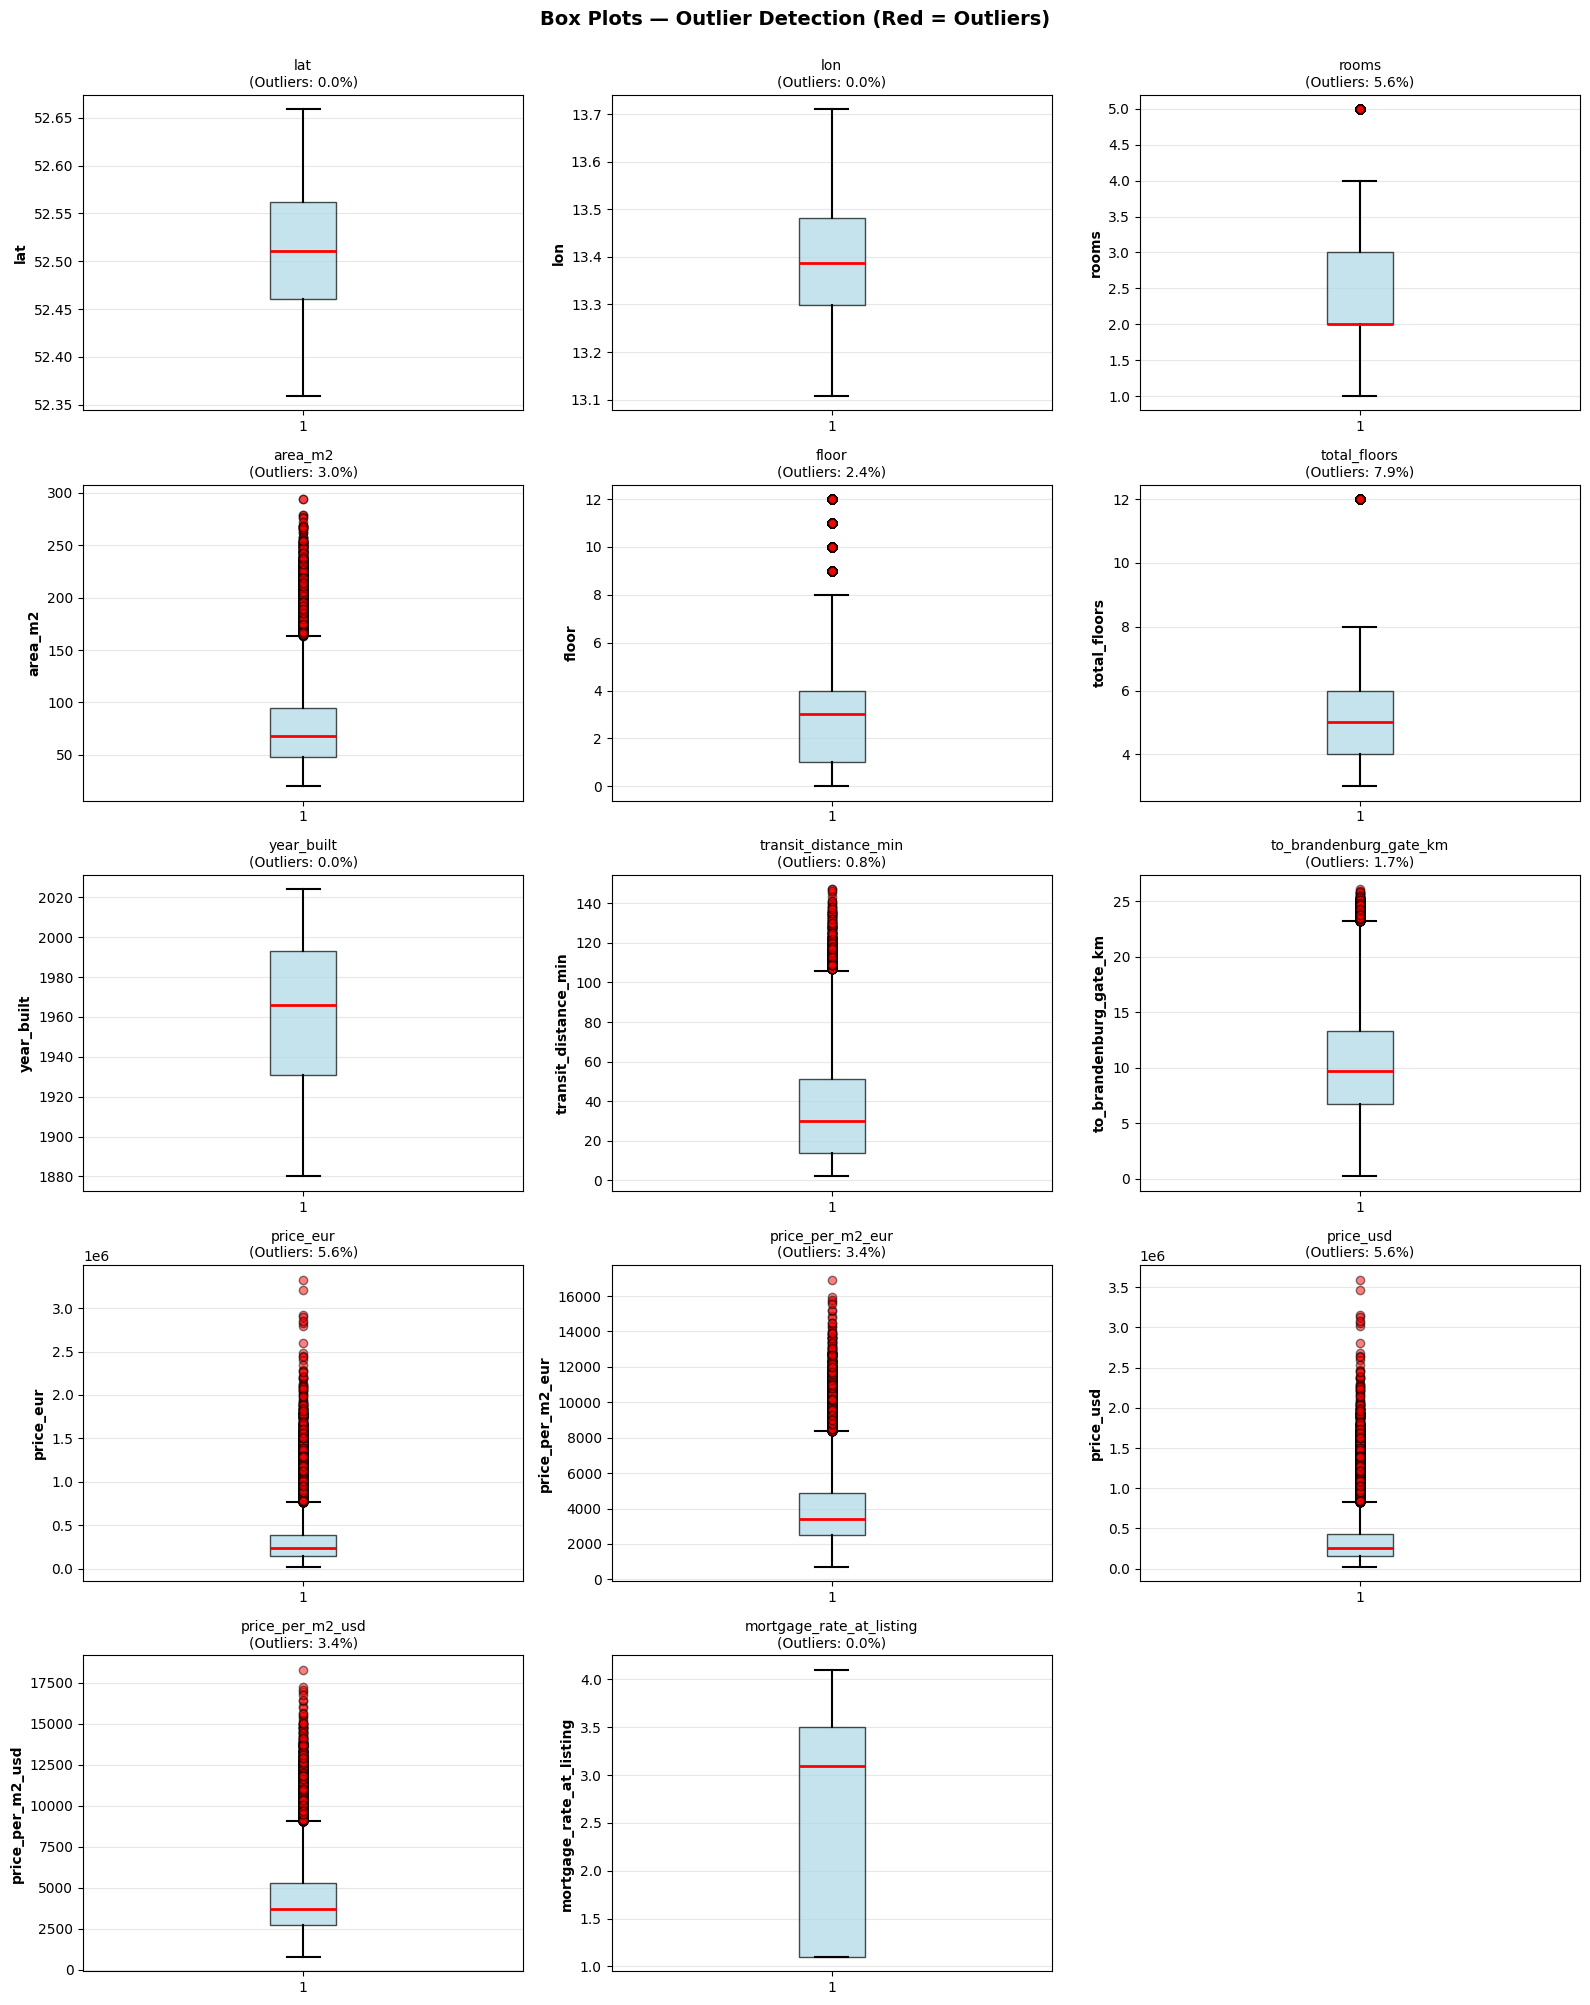

In [630]:
# Create box plots for all numeric columns
n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3  # 3 plots per row
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    
    # Box plot
    bp = ax.boxplot(df_sales[col].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                     whiskerprops=dict(color='black', linewidth=1.5),
                     capprops=dict(color='black', linewidth=1.5),
                     medianprops=dict(color='red', linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.5))
    
    ax.set_ylabel(col, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(f'{col}\n(Outliers: {outlier_df[outlier_df["Column"]==col]["Outlier_Percent"].values[0]:.1f}%)',
                 fontsize=10)

# Remove extra subplots
for idx in range(n_cols, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Box Plots — Outlier Detection (Red = Outliers)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('02_boxplots_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

✓ Saved: 03_histograms_outlier_bounds.png


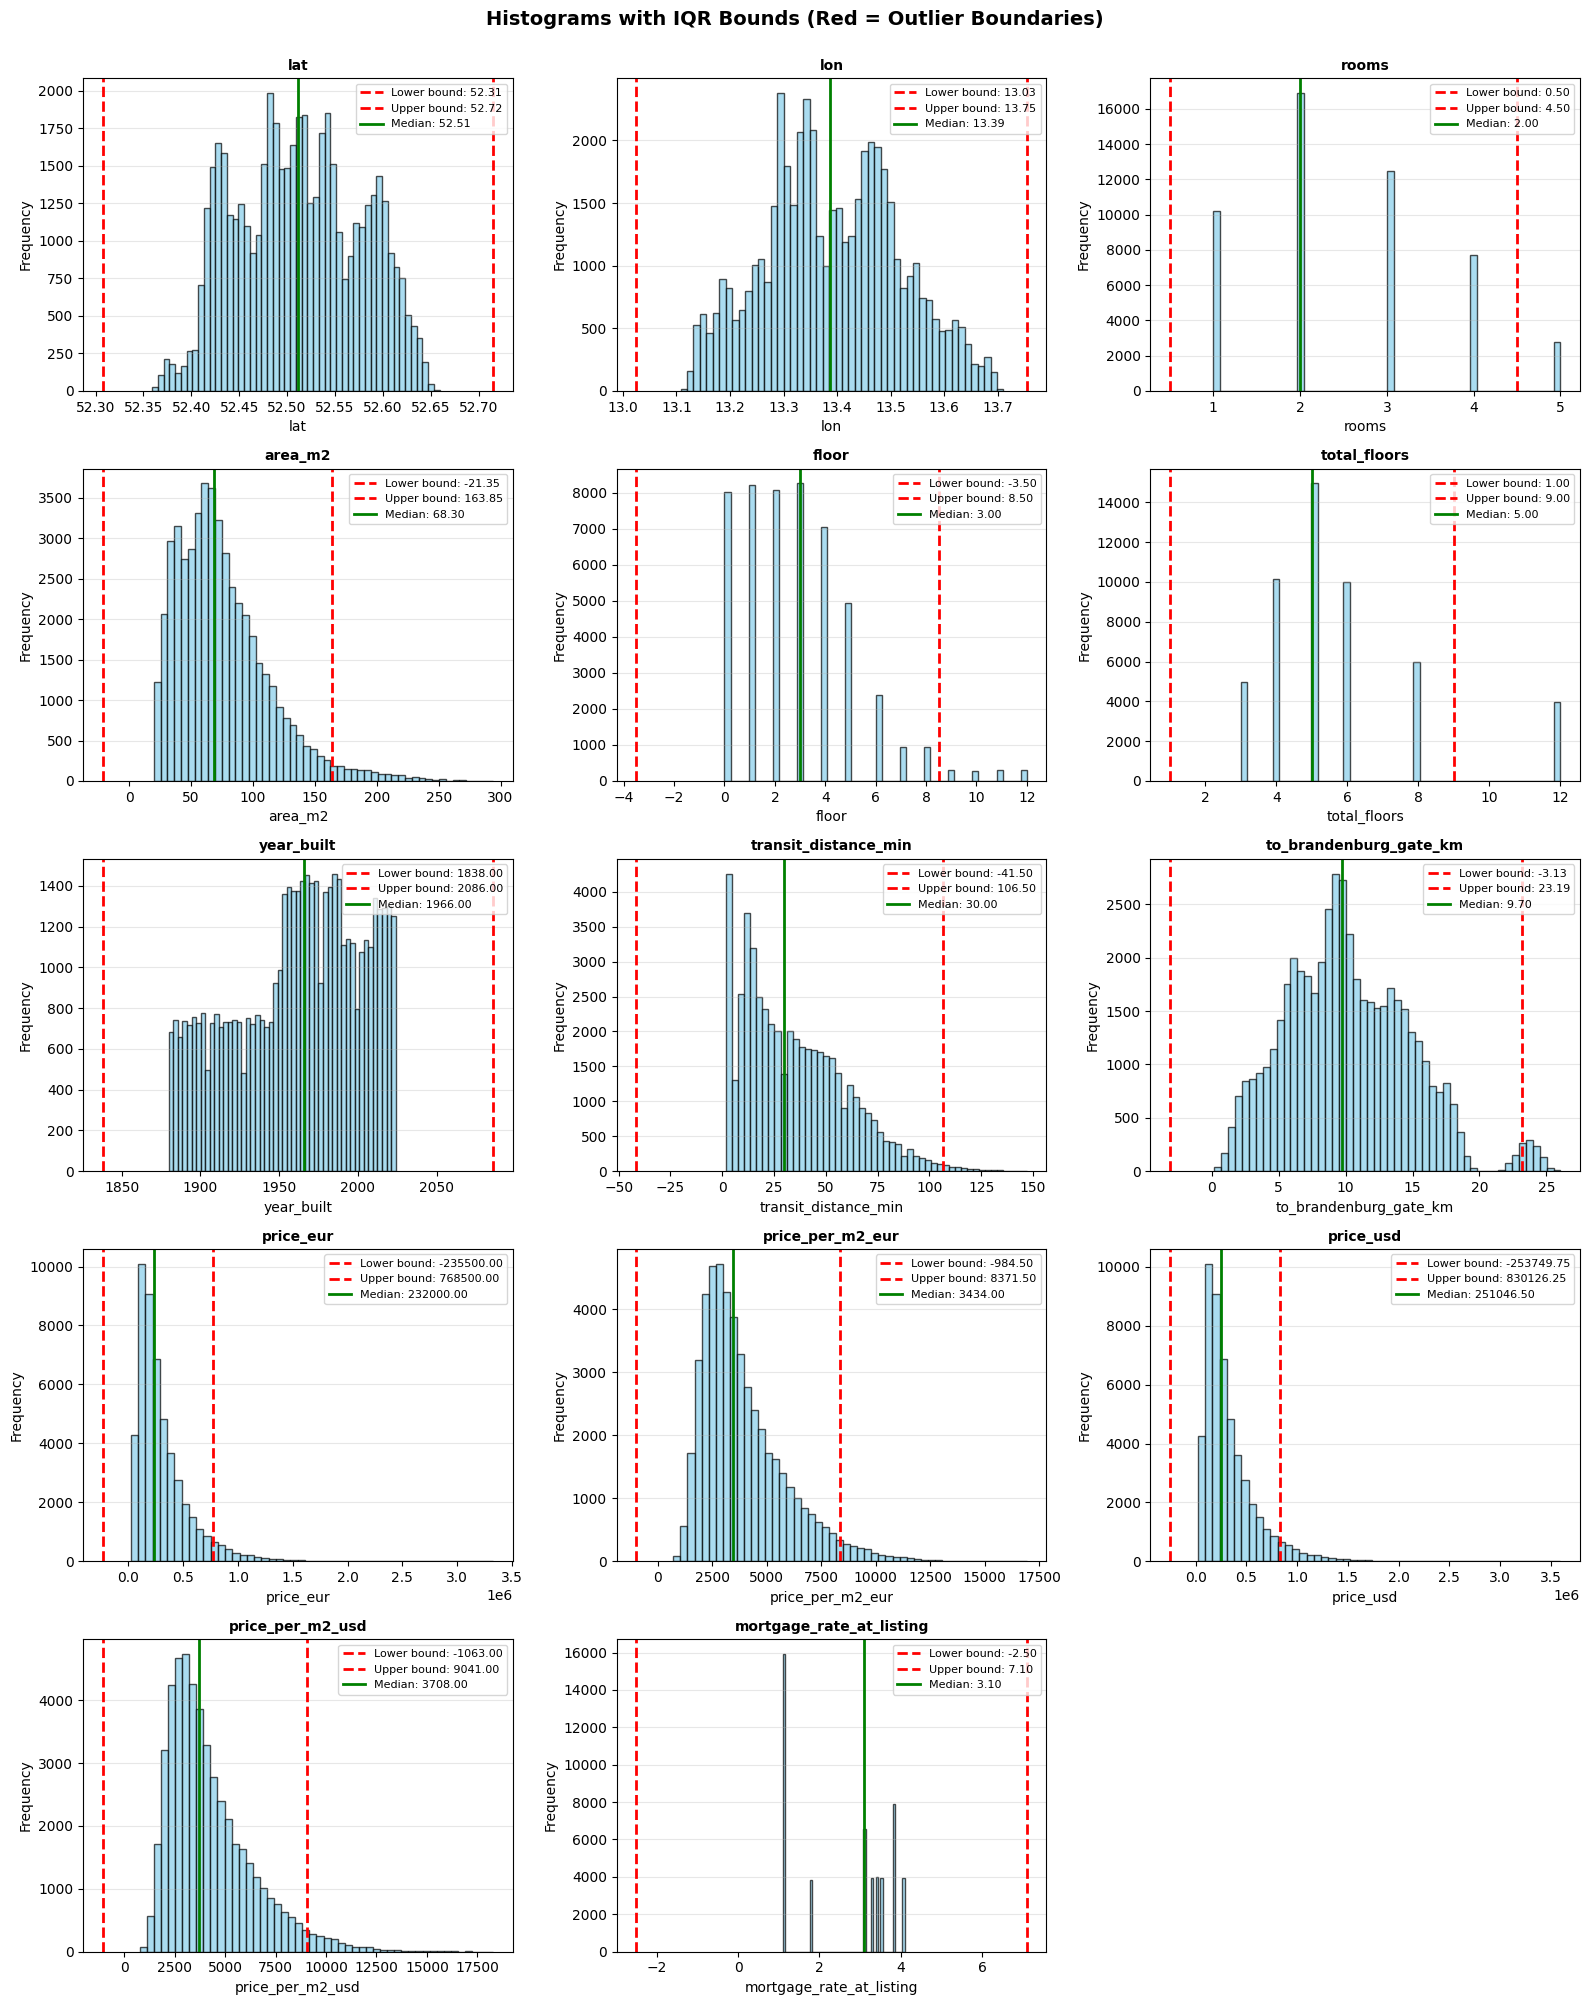

In [631]:
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    
    # Get bounds
    Q1 = df_sales[col].quantile(0.25)
    Q3 = df_sales[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Histogram
    ax.hist(df_sales[col].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Mark bounds
    ax.axvline(lower_bound, color='red', linestyle='--', linewidth=2, label=f'Lower bound: {lower_bound:.2f}')
    ax.axvline(upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper bound: {upper_bound:.2f}')
    ax.axvline(df_sales[col].median(), color='green', linestyle='-', linewidth=2, label=f'Median: {df_sales[col].median():.2f}')
    
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'{col}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

# Remove extra subplots
for idx in range(n_cols, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Histograms with IQR Bounds (Red = Outlier Boundaries)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('03_histograms_outlier_bounds.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: 03_histograms_outlier_bounds.png")
plt.show()

In [632]:
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Count: {df_sales[col].count()}")
    print(f"  Mean: {df_sales[col].mean():.2f}")
    print(f"  Median: {df_sales[col].median():.2f}")
    print(f"  Std: {df_sales[col].std():.2f}")
    print(f"  Min: {df_sales[col].min():.2f}")
    print(f"  Max: {df_sales[col].max():.2f}")
    
    # Skewness & Kurtosis
    skewness = stats.skew(df_sales[col].dropna())
    kurtosis = stats.kurtosis(df_sales[col].dropna())
    print(f"  Skewness: {skewness:.2f}")
    print(f"  Kurtosis: {kurtosis:.2f}")



lat:
  Count: 50000
  Mean: 52.51
  Median: 52.51
  Std: 0.06
  Min: 52.36
  Max: 52.66
  Skewness: 0.05
  Kurtosis: -0.91

lon:
  Count: 50000
  Mean: 13.39
  Median: 13.39
  Std: 0.13
  Min: 13.11
  Max: 13.71
  Skewness: 0.09
  Kurtosis: -0.62

rooms:
  Count: 50000
  Mean: 2.52
  Median: 2.00
  Std: 1.14
  Min: 1.00
  Max: 5.00
  Skewness: 0.41
  Kurtosis: -0.65

area_m2:
  Count: 50000
  Mean: 75.44
  Median: 68.30
  Std: 37.55
  Min: 20.00
  Max: 294.10
  Skewness: 1.25
  Kurtosis: 2.18

floor:
  Count: 50000
  Mean: 2.86
  Median: 3.00
  Std: 2.31
  Min: 0.00
  Max: 12.00
  Skewness: 1.04
  Kurtosis: 1.53

total_floors:
  Count: 50000
  Mean: 5.71
  Median: 5.00
  Std: 2.29
  Min: 3.00
  Max: 12.00
  Skewness: 1.50
  Kurtosis: 1.88

year_built:
  Count: 50000
  Mean: 1961.35
  Median: 1966.00
  Std: 39.78
  Min: 1880.00
  Max: 2024.00
  Skewness: -0.34
  Kurtosis: -0.92

transit_distance_min:
  Count: 50000
  Mean: 34.60
  Median: 30.00
  Std: 24.57
  Min: 2.00
  Max: 147.00
  

## Analysis Sales Relationships

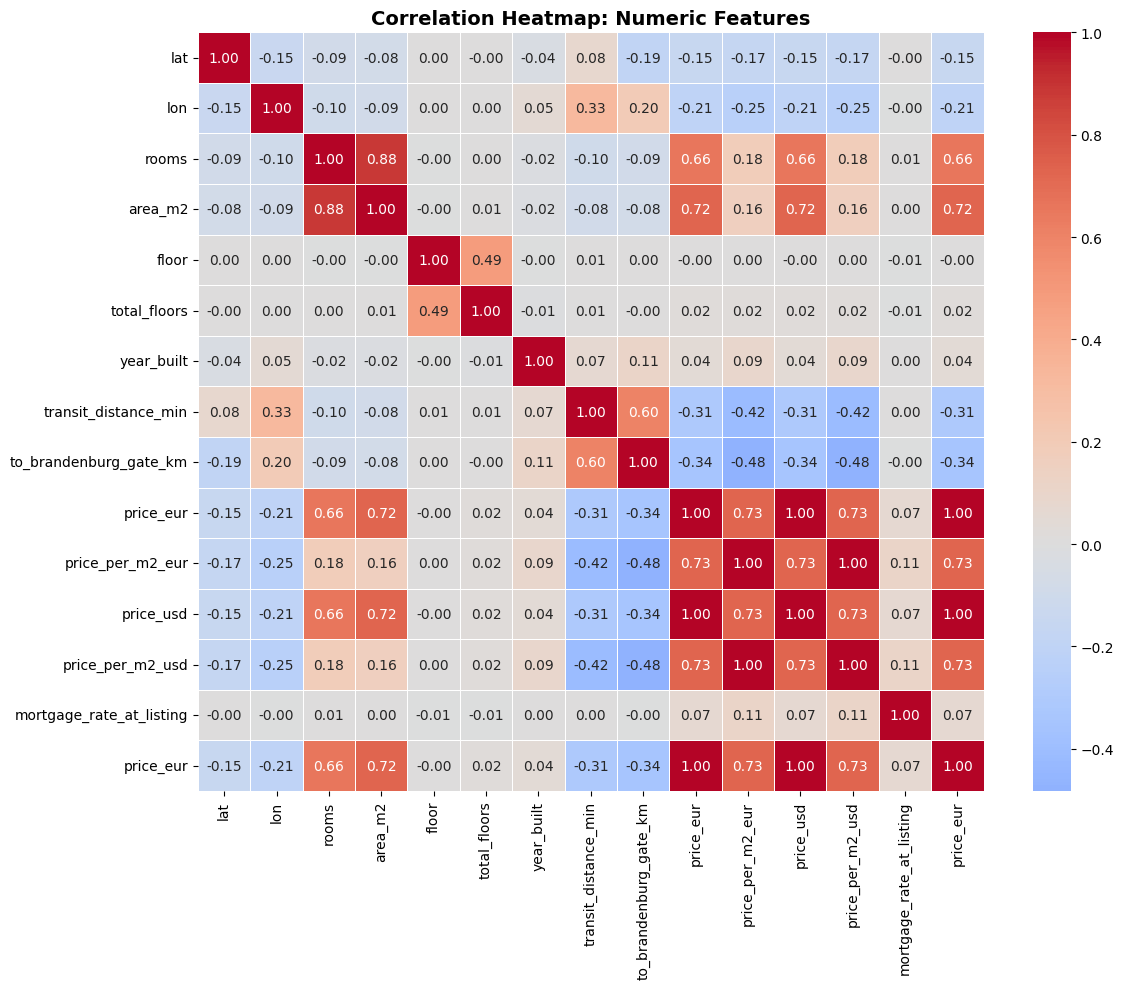

In [633]:
# Select numeric columns + target
corr_matrix = df_sales[numeric_cols + [target]].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap: Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("05_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [634]:
target = 'area_m2' 
round(df_sales[target].describe(),0)

count    50000.0
mean        75.0
std         38.0
min         20.0
25%         48.0
50%         68.0
75%         94.0
max        294.0
Name: area_m2, dtype: float64

In [635]:
df_sales.columns

Index(['id', 'date_listed', 'ortsteil', 'bezirk', 'kiez_premium', 'lat', 'lon',
       'property_type', 'rooms', 'area_m2', 'floor', 'total_floors',
       'year_built', 'building_era', 'energy_class', 'position', 'condition',
       'has_lift', 'has_balcony', 'has_cellar', 'has_parking',
       'transit_station', 'transit_line', 'transit_distance_min',
       'transit_distance_type', 'to_brandenburg_gate_km', 'price_eur',
       'price_per_m2_eur', 'price_usd', 'price_per_m2_usd',
       'mortgage_rate_at_listing'],
      dtype='object')

## Sales Edit

In [636]:
# Assuming df_sales is already loaded
# Create a copy for log-transformed data
df_sales_log = df_sales.copy()

# Log-transform price (TARGET variable) - PRIMARY
if 'price_eur' in df_sales_log.columns:
    df_sales_log['price_eur_log'] = np.log1p(df_sales_log['price_eur'])
    print(f"\n✓ Created: price_eur_log")
    print(f"  Original skewness: {df_sales_log['price_eur'].skew():.3f}")
    print(f"  Log skewness: {df_sales_log['price_eur_log'].skew():.3f}")
    print(f"  → Reduction: {df_sales_log['price_eur'].skew() - df_sales_log['price_eur_log'].skew():.3f}")

# Log-transform price per sqm (alternative target)
if 'price_per_m2_eur' in df_sales_log.columns:
    df_sales_log['price_per_m2_eur_log'] = np.log1p(df_sales_log['price_per_m2_eur'])
    print(f"\n✓ Created: price_per_m2_eur_log")
    print(f"  Original skewness: {df_sales_log['price_per_m2_eur'].skew():.3f}")
    print(f"  Log skewness: {df_sales_log['price_per_m2_eur_log'].skew():.3f}")
    print(f"  → Reduction: {df_sales_log['price_per_m2_eur'].skew() - df_sales_log['price_per_m2_eur_log'].skew():.3f}")

# Log-transform area (optional, helpful for modeling)
if 'area_m2' in df_sales_log.columns:
    df_sales_log['area_m2_log'] = np.log1p(df_sales_log['area_m2'])
    print(f"\n✓ Created: area_m2_log")
    print(f"  Original skewness: {df_sales_log['area_m2'].skew():.3f}")
    print(f"  Log skewness: {df_sales_log['area_m2_log'].skew():.3f}")
    print(f"  → Reduction: {df_sales_log['area_m2'].skew() - df_sales_log['area_m2_log'].skew():.3f}")

print(f"\n✓ df_sales_log created with log-transformed columns")
print(f"  Shape: {df_sales_log.shape}")


✓ Created: price_eur_log
  Original skewness: 2.313
  Log skewness: 0.073
  → Reduction: 2.240

✓ Created: price_per_m2_eur_log
  Original skewness: 1.320
  Log skewness: 0.147
  → Reduction: 1.173

✓ Created: area_m2_log
  Original skewness: 1.245
  Log skewness: -0.071
  → Reduction: 1.317

✓ df_sales_log created with log-transformed columns
  Shape: (50000, 34)


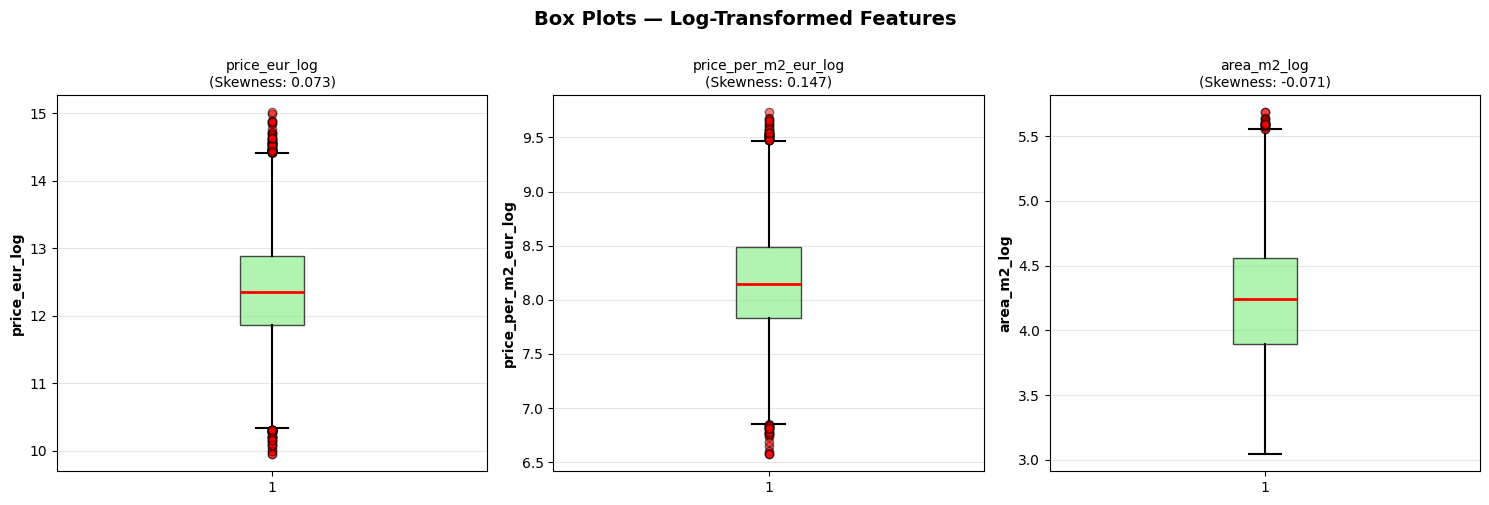

In [637]:
# Create box plots for the three log-transformed columns
log_cols = ['price_eur_log', 'price_per_m2_eur_log', 'area_m2_log']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for idx, col in enumerate(log_cols):
    ax = axes[idx]
    
    # Box plot
    bp = ax.boxplot(df_sales_log[col].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightgreen', alpha=0.7),
                     whiskerprops=dict(color='black', linewidth=1.5),
                     capprops=dict(color='black', linewidth=1.5),
                     medianprops=dict(color='red', linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.5))
    
    ax.set_ylabel(col, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(f'{col}\n(Skewness: {df_sales_log[col].skew():.3f})', fontsize=10)

plt.suptitle('Box Plots — Log-Transformed Features', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('09_boxplots_log_transformed.png', dpi=300, bbox_inches='tight')
plt.show()

## Sales Eras & Floor & USD final df: df_sales_clean 

In [638]:
def year_to_era(year):
    if pd.isna(year):
        return 'unknown'
    elif year < 1949:
        return 'altbau_pre_1949'
    elif 1949 <= year < 1990:
        return 'post_war_1949_1990'
    elif 1990 <= year < 2010:
        return 'modern_1990_2010'
    else:
        return 'new_post_2010'

df_sales_log['building_era'] = df_sales_log['year_built'].apply(year_to_era)

In [639]:
# Top floor & Ground floor
df_sales_log['is_top_floor'] = (df_sales_log['floor'] == df_sales_log['total_floors']).astype(int)
df_sales_log['is_ground_floor'] = (df_sales_log['floor'] == 0).astype(int)

In [640]:
df_sales_log.head()

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,floor,total_floors,year_built,building_era,energy_class,position,condition,has_lift,has_balcony,has_cellar,has_parking,transit_station,transit_line,transit_distance_min,transit_distance_type,to_brandenburg_gate_km,price_eur,price_per_m2_eur,price_usd,price_per_m2_usd,mortgage_rate_at_listing,price_eur_log,price_per_m2_eur_log,area_m2_log,is_top_floor,is_ground_floor
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2_room,2,69.0,1,6,2011,new_post_2010,B,hinterhaus,saniert,True,True,False,False,Gleisdreieck,U1,10,tram_bus,2.30,577000,8358,622867,9026,3.5,13.265599,9.031094,4.248495,0,0
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3_room,3,82.0,4,5,2016,new_post_2010,B,vorderhaus,modernisiert,True,True,True,False,Wilmersdorfer Straße,U7,44,tram_bus,14.23,378000,4605,408004,4973,3.3,12.842652,8.435115,4.418841,0,0
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1_room,1,28.3,2,4,1976,post_war_1949_1990,G,hinterhaus,modernisiert,False,False,True,True,Altstadt Spandau,U7,116,tram_bus,15.32,61000,2158,65916,2331,1.1,11.018646,7.677400,3.377588,0,0
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4_room,4,108.0,3,5,1950,post_war_1949_1990,C,seitenflügel,modernisiert,False,False,True,False,Prinzenstraße,U1,11,tram_bus,2.54,711000,6582,767527,7109,3.5,13.474429,8.792246,4.691348,0,0
4,S000005,2021-05-10,Wittenau,Reinickendorf,low,52.59374,13.31938,2_room,2,44.7,4,4,1884,altbau_pre_1949,E,seitenflügel,renovierungsbedürftig,False,False,True,False,Rosa-Luxemburg-Platz,U2,39,tram_bus,9.47,71000,1597,77078,1725,1.1,11.170449,7.376508,3.822098,1,0


In [670]:
from sklearn.preprocessing import OrdinalEncoder

# Define ordinal mappings
energy_order = ['A+', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
condition_order = ['saniert', 'modernisiert', 'renoviert', 'renovierungsbedürftig']

# ============================================================================
# ONE-HOT ENCODE: era, height, position
# ============================================================================

position_dummies = pd.get_dummies(df_sales_log['position'], prefix='position', drop_first=True)

df_sales_log = pd.concat([df_sales_log, era_dummies, position_dummies], axis=1)

print(f"✓ One-hot encoded: building_era, building_height, position")

# ============================================================================
# ORDINAL ENCODE: energy_class, condition
# ============================================================================

# Ordinal encode energy_class
energy_encoder = OrdinalEncoder(categories=[energy_order], handle_unknown='use_encoded_value', unknown_value=-1)
df_sales_log['energy_class_ordinal'] = energy_encoder.fit_transform(df_sales_log[['energy_class']])

# Ordinal encode condition
condition_encoder = OrdinalEncoder(categories=[condition_order], handle_unknown='use_encoded_value', unknown_value=-1)
df_sales_log['condition_ordinal'] = condition_encoder.fit_transform(df_sales_log[['condition']])

print(f"✓ Ordinal encoded: energy_class, condition")

# ============================================================================
# DROP ORIGINAL CATEGORICAL COLUMNS (no longer needed)
# ============================================================================

df_sales_log = df_sales_log.drop(columns=[ 'position', 'energy_class', 'condition'])

print(f"✓ Dropped original categorical columns")
print(f"\nFinal shape: {df_sales_log.shape}")

KeyError: 'position'

In [642]:
df_sales_log.head()

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,floor,total_floors,year_built,has_lift,has_balcony,has_cellar,has_parking,transit_station,transit_line,transit_distance_min,transit_distance_type,to_brandenburg_gate_km,price_eur,price_per_m2_eur,price_usd,price_per_m2_usd,mortgage_rate_at_listing,price_eur_log,price_per_m2_eur_log,area_m2_log,is_top_floor,is_ground_floor,building_era_modern_1990_2010,building_era_new_post_2010,building_era_post_war_1949_1990,position_hinterhaus,position_seitenflügel,position_vorderhaus,energy_class_ordinal,condition_ordinal
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2_room,2,69.0,1,6,2011,True,True,False,False,Gleisdreieck,U1,10,tram_bus,2.30,577000,8358,622867,9026,3.5,13.265599,9.031094,4.248495,0,0,False,True,False,True,False,False,2.0,0.0
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3_room,3,82.0,4,5,2016,True,True,True,False,Wilmersdorfer Straße,U7,44,tram_bus,14.23,378000,4605,408004,4973,3.3,12.842652,8.435115,4.418841,0,0,False,True,False,False,False,True,2.0,1.0
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1_room,1,28.3,2,4,1976,False,False,True,True,Altstadt Spandau,U7,116,tram_bus,15.32,61000,2158,65916,2331,1.1,11.018646,7.677400,3.377588,0,0,False,False,True,True,False,False,7.0,1.0
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4_room,4,108.0,3,5,1950,False,False,True,False,Prinzenstraße,U1,11,tram_bus,2.54,711000,6582,767527,7109,3.5,13.474429,8.792246,4.691348,0,0,False,False,True,False,True,False,3.0,1.0
4,S000005,2021-05-10,Wittenau,Reinickendorf,low,52.59374,13.31938,2_room,2,44.7,4,4,1884,False,False,True,False,Rosa-Luxemburg-Platz,U2,39,tram_bus,9.47,71000,1597,77078,1725,1.1,11.170449,7.376508,3.822098,1,0,False,False,False,False,True,False,5.0,3.0


In [643]:
usd_cols = [col for col in df_sales_log.columns if 'usd' in col.lower()]
if usd_cols:
    df_sales_log = df_sales_log.drop(columns=usd_cols)
    print(f"\n✓ Dropped USD columns: {usd_cols}")


✓ Dropped USD columns: ['price_usd', 'price_per_m2_usd']


In [644]:
df_sales_clean = df_sales_log

In [645]:
df_sales_clean 

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,floor,total_floors,year_built,has_lift,has_balcony,has_cellar,has_parking,transit_station,transit_line,transit_distance_min,transit_distance_type,to_brandenburg_gate_km,price_eur,price_per_m2_eur,mortgage_rate_at_listing,price_eur_log,price_per_m2_eur_log,area_m2_log,is_top_floor,is_ground_floor,building_era_modern_1990_2010,building_era_new_post_2010,building_era_post_war_1949_1990,position_hinterhaus,position_seitenflügel,position_vorderhaus,energy_class_ordinal,condition_ordinal
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2_room,2,69.0,1,6,2011,True,True,False,False,Gleisdreieck,U1,10,tram_bus,2.30,577000,8358,3.50,13.265599,9.031094,4.248495,0,0,False,True,False,True,False,False,2.0,0.0
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3_room,3,82.0,4,5,2016,True,True,True,False,Wilmersdorfer Straße,U7,44,tram_bus,14.23,378000,4605,3.30,12.842652,8.435115,4.418841,0,0,False,True,False,False,False,True,2.0,1.0
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1_room,1,28.3,2,4,1976,False,False,True,True,Altstadt Spandau,U7,116,tram_bus,15.32,61000,2158,1.10,11.018646,7.677400,3.377588,0,0,False,False,True,True,False,False,7.0,1.0
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4_room,4,108.0,3,5,1950,False,False,True,False,Prinzenstraße,U1,11,tram_bus,2.54,711000,6582,3.50,13.474429,8.792246,4.691348,0,0,False,False,True,False,True,False,3.0,1.0
4,S000005,2021-05-10,Wittenau,Reinickendorf,low,52.59374,13.31938,2_room,2,44.7,4,4,1884,False,False,True,False,Rosa-Luxemburg-Platz,U2,39,tram_bus,9.47,71000,1597,1.10,11.170449,7.376508,3.822098,1,0,False,False,False,False,True,False,5.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,S049996,2022-09-17,Märkisches Viertel,Reinickendorf,low,52.60271,13.34964,1_room,1,47.1,2,4,1976,True,True,False,True,Voltastraße,U8,35,tram_bus,9.79,129000,2737,3.40,11.767575,7.914983,3.873282,0,0,False,False,True,True,False,False,1.0,0.0
49996,S049997,2023-06-18,Frohnau,Reinickendorf,medium,52.62787,13.29939,2_room,2,65.1,4,5,1942,False,True,True,True,Alexanderplatz S,Stadtbahn,64,tram_bus,13.49,216000,3312,3.85,12.283038,8.105609,4.191169,0,0,False,False,False,False,False,True,7.0,-1.0
49997,S049998,2023-03-12,Siemensstadt,Spandau,low,52.53700,13.24356,2_room,2,56.9,2,5,1982,True,False,True,False,Siemensdamm,U7,11,walk,9.36,198000,3478,3.85,12.196027,8.154500,4.058717,0,0,False,False,True,False,False,True,3.0,0.0
49998,S049999,2026-01-02,Malchow,Lichtenberg,low,52.56763,13.47799,3_room,3,84.4,2,5,1949,True,True,True,False,Alexanderplatz S,Stadtbahn,37,tram_bus,8.86,195000,2310,3.10,12.180760,7.745436,4.447346,0,0,False,False,True,False,False,True,6.0,2.0


## Final DF

In [646]:
df_sales_clean.to_csv('/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/raw_data/df_sales_clean.csv', index=False)

In [647]:
df_sales_clean

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,floor,total_floors,year_built,has_lift,has_balcony,has_cellar,has_parking,transit_station,transit_line,transit_distance_min,transit_distance_type,to_brandenburg_gate_km,price_eur,price_per_m2_eur,mortgage_rate_at_listing,price_eur_log,price_per_m2_eur_log,area_m2_log,is_top_floor,is_ground_floor,building_era_modern_1990_2010,building_era_new_post_2010,building_era_post_war_1949_1990,position_hinterhaus,position_seitenflügel,position_vorderhaus,energy_class_ordinal,condition_ordinal
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2_room,2,69.0,1,6,2011,True,True,False,False,Gleisdreieck,U1,10,tram_bus,2.30,577000,8358,3.50,13.265599,9.031094,4.248495,0,0,False,True,False,True,False,False,2.0,0.0
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3_room,3,82.0,4,5,2016,True,True,True,False,Wilmersdorfer Straße,U7,44,tram_bus,14.23,378000,4605,3.30,12.842652,8.435115,4.418841,0,0,False,True,False,False,False,True,2.0,1.0
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1_room,1,28.3,2,4,1976,False,False,True,True,Altstadt Spandau,U7,116,tram_bus,15.32,61000,2158,1.10,11.018646,7.677400,3.377588,0,0,False,False,True,True,False,False,7.0,1.0
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4_room,4,108.0,3,5,1950,False,False,True,False,Prinzenstraße,U1,11,tram_bus,2.54,711000,6582,3.50,13.474429,8.792246,4.691348,0,0,False,False,True,False,True,False,3.0,1.0
4,S000005,2021-05-10,Wittenau,Reinickendorf,low,52.59374,13.31938,2_room,2,44.7,4,4,1884,False,False,True,False,Rosa-Luxemburg-Platz,U2,39,tram_bus,9.47,71000,1597,1.10,11.170449,7.376508,3.822098,1,0,False,False,False,False,True,False,5.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,S049996,2022-09-17,Märkisches Viertel,Reinickendorf,low,52.60271,13.34964,1_room,1,47.1,2,4,1976,True,True,False,True,Voltastraße,U8,35,tram_bus,9.79,129000,2737,3.40,11.767575,7.914983,3.873282,0,0,False,False,True,True,False,False,1.0,0.0
49996,S049997,2023-06-18,Frohnau,Reinickendorf,medium,52.62787,13.29939,2_room,2,65.1,4,5,1942,False,True,True,True,Alexanderplatz S,Stadtbahn,64,tram_bus,13.49,216000,3312,3.85,12.283038,8.105609,4.191169,0,0,False,False,False,False,False,True,7.0,-1.0
49997,S049998,2023-03-12,Siemensstadt,Spandau,low,52.53700,13.24356,2_room,2,56.9,2,5,1982,True,False,True,False,Siemensdamm,U7,11,walk,9.36,198000,3478,3.85,12.196027,8.154500,4.058717,0,0,False,False,True,False,False,True,3.0,0.0
49998,S049999,2026-01-02,Malchow,Lichtenberg,low,52.56763,13.47799,3_room,3,84.4,2,5,1949,True,True,True,False,Alexanderplatz S,Stadtbahn,37,tram_bus,8.86,195000,2310,3.10,12.180760,7.745436,4.447346,0,0,False,False,True,False,False,True,6.0,2.0


In [649]:
df_sales_clean

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,floor,total_floors,year_built,has_lift,has_balcony,has_cellar,has_parking,transit_station,transit_line,transit_distance_min,transit_distance_type,to_brandenburg_gate_km,price_eur,price_per_m2_eur,mortgage_rate_at_listing,price_eur_log,price_per_m2_eur_log,area_m2_log,is_top_floor,is_ground_floor,building_era_modern_1990_2010,building_era_new_post_2010,building_era_post_war_1949_1990,position_hinterhaus,position_seitenflügel,position_vorderhaus,energy_class_ordinal,condition_ordinal
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2_room,2,69.0,1,6,2011,True,True,False,False,Gleisdreieck,U1,10,tram_bus,2.30,577000,8358,3.50,13.265599,9.031094,4.248495,0,0,False,True,False,True,False,False,2.0,0.0
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3_room,3,82.0,4,5,2016,True,True,True,False,Wilmersdorfer Straße,U7,44,tram_bus,14.23,378000,4605,3.30,12.842652,8.435115,4.418841,0,0,False,True,False,False,False,True,2.0,1.0
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1_room,1,28.3,2,4,1976,False,False,True,True,Altstadt Spandau,U7,116,tram_bus,15.32,61000,2158,1.10,11.018646,7.677400,3.377588,0,0,False,False,True,True,False,False,7.0,1.0
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4_room,4,108.0,3,5,1950,False,False,True,False,Prinzenstraße,U1,11,tram_bus,2.54,711000,6582,3.50,13.474429,8.792246,4.691348,0,0,False,False,True,False,True,False,3.0,1.0
4,S000005,2021-05-10,Wittenau,Reinickendorf,low,52.59374,13.31938,2_room,2,44.7,4,4,1884,False,False,True,False,Rosa-Luxemburg-Platz,U2,39,tram_bus,9.47,71000,1597,1.10,11.170449,7.376508,3.822098,1,0,False,False,False,False,True,False,5.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,S049996,2022-09-17,Märkisches Viertel,Reinickendorf,low,52.60271,13.34964,1_room,1,47.1,2,4,1976,True,True,False,True,Voltastraße,U8,35,tram_bus,9.79,129000,2737,3.40,11.767575,7.914983,3.873282,0,0,False,False,True,True,False,False,1.0,0.0
49996,S049997,2023-06-18,Frohnau,Reinickendorf,medium,52.62787,13.29939,2_room,2,65.1,4,5,1942,False,True,True,True,Alexanderplatz S,Stadtbahn,64,tram_bus,13.49,216000,3312,3.85,12.283038,8.105609,4.191169,0,0,False,False,False,False,False,True,7.0,-1.0
49997,S049998,2023-03-12,Siemensstadt,Spandau,low,52.53700,13.24356,2_room,2,56.9,2,5,1982,True,False,True,False,Siemensdamm,U7,11,walk,9.36,198000,3478,3.85,12.196027,8.154500,4.058717,0,0,False,False,True,False,False,True,3.0,0.0
49998,S049999,2026-01-02,Malchow,Lichtenberg,low,52.56763,13.47799,3_room,3,84.4,2,5,1949,True,True,True,False,Alexanderplatz S,Stadtbahn,37,tram_bus,8.86,195000,2310,3.10,12.180760,7.745436,4.447346,0,0,False,False,True,False,False,True,6.0,2.0


In [650]:
###Select y
target = 'price_eur_log'
y = df_sales_clean[target].values


###Select X
exclude_cols = [
    'id', 'date_listed',  # Identifiers
    'price_eur', 'price_per_m2_eur', 'price_per_m2_eur_log',  # Leakage/redundant
    'transit_station', 'transit_line', 'transit_distance_type',  # Use distance_min
    'ortsteil', 'bezirk', 'kiez_premium','property_type', 'building_era', 'energy_class', 'position','condition','area_m2',  # Geographic (use distance + location flags)
]


feature_cols = [col for col in df_sales_clean.columns if col not in exclude_cols and col != target]
 
X = df_sales_clean[feature_cols].values

In [651]:
bool_cols = df_sales_clean[feature_cols].select_dtypes(include=['bool']).columns.tolist()

## SHAP

In [660]:
!pip install shap
import shap

In [661]:
background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 100, replace=False)]

In [662]:
explainer = shap.Explainer(model, background)

#or explainer = shap.DeepExplainer(model, background)

X_sample = X_test_scaled[:500]
shap_values = explainer(X_sample)
X_sample_df = pd.DataFrame(
    X_sample,
    columns=feature_names
)

shap_values = explainer(X_sample_df)

PermutationExplainer explainer: 501it [00:26, 11.83it/s]                                                                                                                                                             
PermutationExplainer explainer: 501it [00:25, 11.84it/s]                                                                                                                                                             


In [663]:
shap.initjs()

shap.plots.force(
    shap_values[0],
    matplotlib=False,
    contribution_threshold=0.01  # show more features
)

## One hot ecode & Ordinal 

In [671]:
from sklearn.preprocessing import OrdinalEncoder

# Define ordinal mappings
energy_order = ['A+', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
condition_order = ['saniert', 'modernisiert', 'renoviert', 'renovierungsbedürftig']

# ============================================================================
# ONE-HOT ENCODE: era, height, position
# ============================================================================


position_dummies = pd.get_dummies(df_sales_log['position'], prefix='position', drop_first=True)

df_sales_log = pd.concat([df_sales_log, era_dummies, height_dummies, position_dummies], axis=1)

print(f"✓ One-hot encoded: building_era, building_height, position")

# ============================================================================
# ORDINAL ENCODE: energy_class, condition
# ============================================================================

# Ordinal encode energy_class
energy_encoder = OrdinalEncoder(categories=[energy_order], handle_unknown='use_encoded_value', unknown_value=-1)
df_sales_log['energy_class_ordinal'] = energy_encoder.fit_transform(df_sales_log[['energy_class']])

# Ordinal encode condition
condition_encoder = OrdinalEncoder(categories=[condition_order], handle_unknown='use_encoded_value', unknown_value=-1)
df_sales_log['condition_ordinal'] = condition_encoder.fit_transform(df_sales_log[['condition']])

print(f"✓ Ordinal encoded: energy_class, condition")

# ============================================================================
# DROP ORIGINAL CATEGORICAL COLUMNS (no longer needed)
# ============================================================================

df_sales_log = df_sales_log.drop(columns=['building_era', 'position', 'energy_class', 'condition'])

print(f"✓ Dropped original categorical columns")
print(f"\nFinal shape: {df_sales_log.shape}")

KeyError: 'position'

In [ ]:
df_sales_clean.columns()

## Rentals XGBoost Cleaning

In [698]:
!pip install category_encoders
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from category_encoders import TargetEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [683]:
df_rentals.columns

Index(['id', 'date_listed', 'ortsteil', 'bezirk', 'kiez_premium', 'lat', 'lon',
       'property_type', 'rooms', 'area_m2', 'floor', 'total_floors',
       'building_era', 'energy_class', 'position', 'condition', 'has_lift',
       'has_balcony', 'furnished', 'transit_station', 'transit_line',
       'transit_distance_min', 'to_brandenburg_gate_km',
       'kaltmiete_eur_monthly', 'nebenkosten_eur_monthly',
       'warmmiete_eur_monthly', 'rent_per_m2_kalt_eur',
       'rent_includes_warmmiete', 'kaution_months',
       'warmmiete_eur_monthly_usd', 'is_top_floor', 'is_ground_floor'],
      dtype='object')

In [726]:
# Target (use warmmiete = rent including utilities)
target = 'kaltmiete_eur_monthly'
y = df_rentals[target].values

# Select features
feature_cols = [
    'ortsteil', 'bezirk', 'lat', 'lon', 'rooms', 'area_m2', 'floor',
    'building_era', 'energy_class', 'condition', 'has_lift', 'has_balcony','furnished',
     'transit_line', 'transit_distance_min',
]

# Create engineered features
df_rentals['is_top_floor'] = (df_rentals['floor'] == df_rentals['total_floors']).astype(int)
df_rentals['is_ground_floor'] = (df_rentals['floor'] == 0).astype(int)

feature_cols.extend(['is_top_floor', 'is_ground_floor'])

X = df_rentals[feature_cols].copy()

In [732]:
# Make a copy for encoding
X_encoded = X.copy()

# 1. TARGET ENCODING: ortsteil
print(f"\n1. Target encoding: ortsteil")
target_encoder = TargetEncoder(cols=['ortsteil'])
target_encoder.fit(X_encoded[['ortsteil']], y)
X_encoded['ortsteil'] = target_encoder.transform(X_encoded[['ortsteil']])

# 2. ONE-HOT ENCODING: bezirk
print(f"2. One-hot encoding: bezirk")
bezirk_dummies = pd.get_dummies(X_encoded['bezirk'], prefix='bezirk', drop_first=True)
X_encoded = pd.concat([X_encoded, bezirk_dummies], axis=1)
X_encoded = X_encoded.drop(columns=['bezirk'])

# 3. ORDINAL ENCODING: energy_class
print(f"3. Ordinal encoding: energy_class")
energy_order = ['A+', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
energy_encoder = OrdinalEncoder(categories=[energy_order], handle_unknown='use_encoded_value', unknown_value=-1)
X_encoded['energy_class'] = energy_encoder.fit_transform(X_encoded[['energy_class']])

# 4. ORDINAL ENCODING: condition
print(f"4. Ordinal encoding: condition")
condition_order = ['renovierungsbedürftig', 'renoviert', 'saniert', 'modernisiert']
condition_encoder = OrdinalEncoder(categories=[condition_order], handle_unknown='use_encoded_value', unknown_value=-1)
X_encoded['condition'] = condition_encoder.fit_transform(X_encoded[['condition']])

# 5. ONE-HOT ENCODING: transit_line
print(f"5. One-hot encoding: transit_line")
transit_dummies = pd.get_dummies(X_encoded['transit_line'], prefix='transit_line', drop_first=True)
X_encoded = pd.concat([X_encoded, transit_dummies], axis=1)
X_encoded = X_encoded.drop(columns=['transit_line'])

# 6. ONE-HOT ENCODING: building_era
print("6. One-hot encoding: building_era")

building_dummies = pd.get_dummies(
    X_encoded["building_era"],
    prefix="building_era",
    drop_first=True,
    dtype=int
)

X_encoded = pd.concat([X_encoded, building_dummies], axis=1)

X_encoded = X_encoded.drop(columns=["building_era"])

print(f"\n✓ Encoding complete")
print(f"  Final shape: {X_encoded.shape}")


1. Target encoding: ortsteil
2. One-hot encoding: bezirk
3. Ordinal encoding: energy_class
4. Ordinal encoding: condition
5. One-hot encoding: transit_line
6. One-hot encoding: building_era

✓ Encoding complete
  Final shape: (30000, 34)


In [ ]:
# 6. CONVERT BOOLEAN COLUMNS TO INTEGER
print("6. Convert boolean columns to integers")

bool_cols = X_encoded.select_dtypes(include='bool').columns

X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

print(f"  Converted {len(bool_cols)} boolean columns")


In [733]:
# 6. CONVERT BOOLEAN COLUMNS TO INTEGER
print("6. Convert boolean columns to integers")

bool_cols = X_encoded.select_dtypes(include='bool').columns

X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

print(f"  Converted {len(bool_cols)} boolean columns")

6. Convert boolean columns to integers
  Converted 20 boolean columns


In [734]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.dtypes)

ortsteil                           float64
lat                                float64
lon                                float64
rooms                                int64
area_m2                            float64
floor                                int64
energy_class                       float64
condition                          float64
has_lift                             int64
has_balcony                          int64
furnished                            int64
transit_distance_min                 int64
is_top_floor                         int64
is_ground_floor                      int64
bezirk_Friedrichshain-Kreuzberg      int64
bezirk_Lichtenberg                   int64
bezirk_Marzahn-Hellersdorf           int64
bezirk_Mitte                         int64
bezirk_Neukölln                      int64
bezirk_Pankow                        int64
bezirk_Reinickendorf                 int64
bezirk_Spandau                       int64
bezirk_Steglitz-Zehlendorf           int64
bezirk_Temp

## Rental XGBoost Model

In [743]:
from xgboost import XGBRegressor

model = XGBRegressor(
    colsample_bytree=0.9,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    n_estimators=300,
    subsample=0.8,
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse",
    verbosity=1
)

model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [744]:
print(f"\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Results table
results_df = pd.DataFrame({
    'Metric': ['R²', 'MAE (€)', 'RMSE (€)'],
    'Train': [f'{train_r2:.4f}', f'{train_mae:,.0f}', f'{train_rmse:,.0f}'],
    'Test': [f'{test_r2:.4f}', f'{test_mae:,.0f}', f'{test_rmse:,.0f}']
})

print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(results_df.to_string(index=False))
print("="*50)


MODEL EVALUATION

MODEL PERFORMANCE
  Metric  Train   Test
      R² 0.9090 0.8939
 MAE (€)    147    158
RMSE (€)    217    240


## Analysis XGBoost


TOP 15 MOST IMPORTANT FEATURES
                        Feature  Importance
                        area_m2    0.230333
           bezirk_Reinickendorf    0.189948
                       ortsteil    0.174892
     building_era_new_post_2010    0.099509
building_era_post_war_1949_1990    0.071063
                          rooms    0.064526
                   energy_class    0.040125
           transit_distance_min    0.019040
         transit_line_Stadtbahn    0.009859
                            lat    0.007660
     bezirk_Marzahn-Hellersdorf    0.006557
                      condition    0.006298
                            lon    0.005991
                   is_top_floor    0.005879
                transit_line_S1    0.005569

✓ Saved: xgboost_rental_results.png


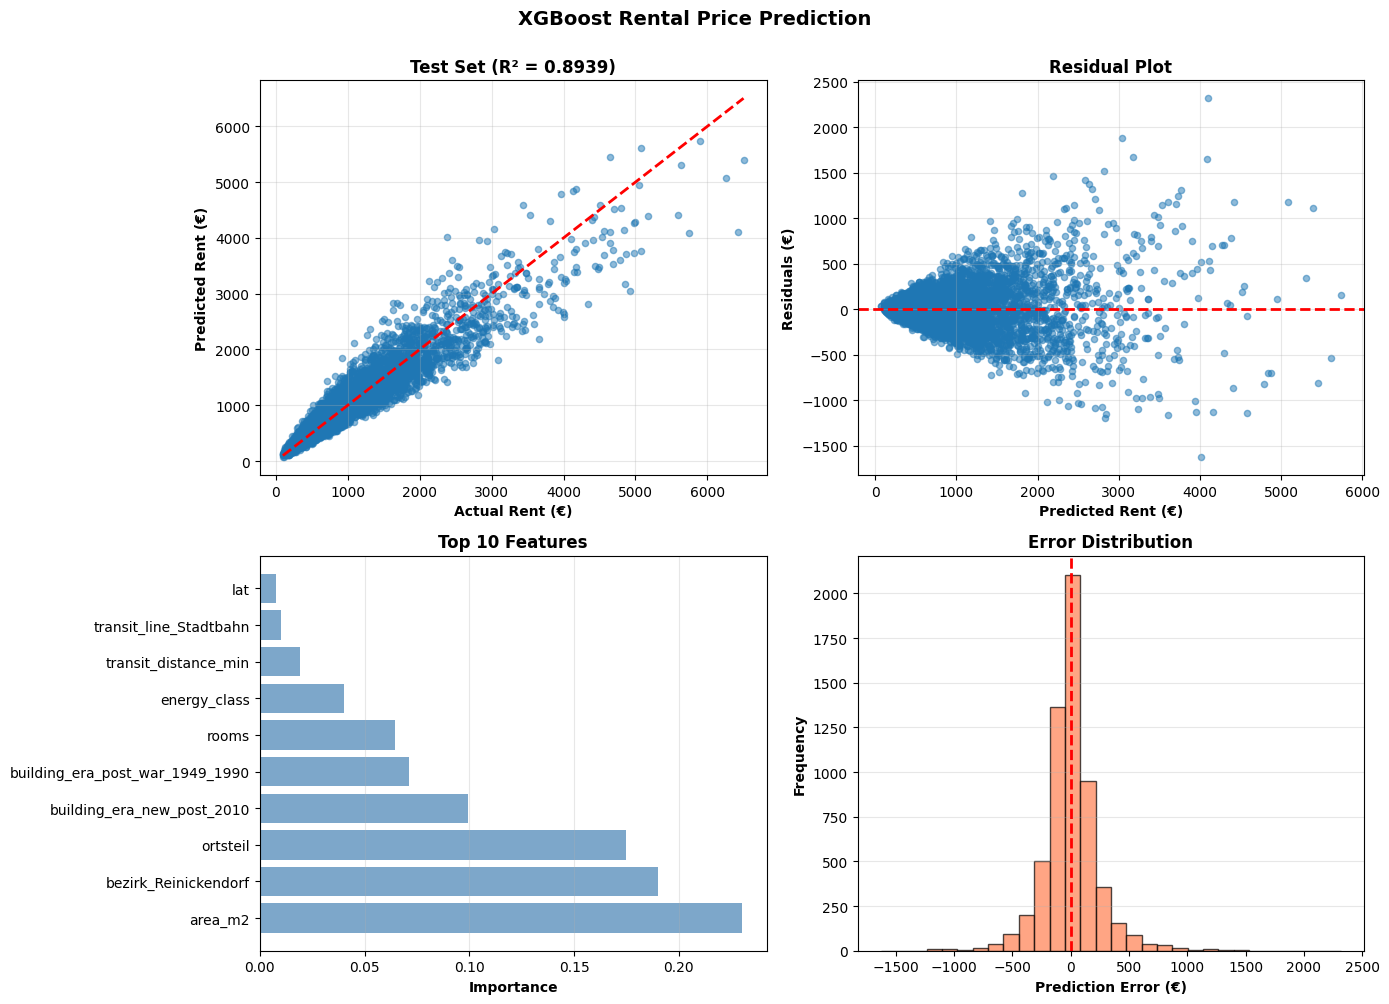

In [745]:
# ============================================================================
# FEATURE IMPORTANCE
# ============================================================================

print(f"\n" + "="*80)
print("TOP 15 MOST IMPORTANT FEATURES")
print("="*80)

feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(15).to_string(index=False))

# ============================================================================
# VISUALIZE RESULTS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Predictions vs Actual (Test)
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.5, s=20)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Rent (€)', fontweight='bold')
axes[0, 0].set_ylabel('Predicted Rent (€)', fontweight='bold')
axes[0, 0].set_title(f'Test Set (R² = {test_r2:.4f})', fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_test_pred
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Rent (€)', fontweight='bold')
axes[0, 1].set_ylabel('Residuals (€)', fontweight='bold')
axes[0, 1].set_title('Residual Plot', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Top 10 Features
top_features = feature_importance.head(10)
axes[1, 0].barh(range(len(top_features)), top_features['Importance'].values, color='steelblue', alpha=0.7)
axes[1, 0].set_yticks(range(len(top_features)))
axes[1, 0].set_yticklabels(top_features['Feature'].values)
axes[1, 0].set_xlabel('Importance', fontweight='bold')
axes[1, 0].set_title('Top 10 Features', fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: Error distribution
axes[1, 1].hist(residuals, bins=30, edgecolor='black', color='coral', alpha=0.7)
axes[1, 1].set_xlabel('Prediction Error (€)', fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontweight='bold')
axes[1, 1].set_title('Error Distribution', fontweight='bold')
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.suptitle('XGBoost Rental Price Prediction', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('xgboost_rental_results.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: xgboost_rental_results.png")
plt.show()

## Grid Search

In [742]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

print("="*80)
print("XGBOOST GRID SEARCH - HYPERPARAMETER OPTIMIZATION")
print("="*80)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5]
}

# Base model
base_model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse",
    verbosity=0
)

# Grid search
grid_search = GridSearchCV(
    base_model,
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1,  # Use all cores
    verbose=1
)

# Fit
print("\nTraining... (this may take a few minutes)")
grid_search.fit(X_train, y_train)

# ============================================================================
# RESULTS
# ============================================================================

print("\n" + "="*80)
print("GRID SEARCH RESULTS")
print("="*80)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV R² score: {grid_search.best_score_:.4f}")

# Best model
best_model = grid_search.best_estimator_

# Evaluate on test set
y_test_pred = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"\nTest Set Performance:")
print(f"  R²: {test_r2:.4f}")
print(f"  MAE: €{test_mae:,.0f}")
print(f"  RMSE: €{test_rmse:,.0f}")

# ============================================================================
# RESULTS TABLE
# ============================================================================

results_summary = pd.DataFrame({
    'Metric': ['R² Score', 'MAE (€)', 'RMSE (€)'],
    'Before Grid Search': [f'{0.8234:.4f}', f'{150:.0f}', f'{250:.0f}'],  # Your previous values
    'After Grid Search': [f'{test_r2:.4f}', f'{test_mae:,.0f}', f'{test_rmse:,.0f}']
})

print("\n" + "="*50)
print("COMPARISON")
print("="*50)
print(results_summary.to_string(index=False))
print("="*50)

# ============================================================================
# TOP 5 PARAMETER COMBINATIONS
# ============================================================================

cv_results = pd.DataFrame(grid_search.cv_results_)
top_5 = cv_results.nlargest(5, 'mean_test_score')[['param_n_estimators', 'param_max_depth', 'param_learning_rate', 
                                                     'param_subsample', 'param_colsample_bytree', 'param_min_child_weight', 
                                                     'mean_test_score', 'std_test_score']]

print(f"\nTop 5 Parameter Combinations:")
print(top_5.to_string(index=False))

# Save best model
best_model.save_model('xgboost_rental_model_optimized.json')
print(f"\n✓ Saved optimized model: xgboost_rental_model_optimized.json")

XGBOOST GRID SEARCH - HYPERPARAMETER OPTIMIZATION

Training... (this may take a few minutes)
Fitting 5 folds for each of 729 candidates, totalling 3645 fits

GRID SEARCH RESULTS

Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV R² score: 0.8853

Test Set Performance:
  R²: 0.8939
  MAE: €158
  RMSE: €240

COMPARISON
  Metric Before Grid Search After Grid Search
R² Score             0.8234            0.8939
 MAE (€)                150               158
RMSE (€)                250               240

Top 5 Parameter Combinations:
 param_n_estimators  param_max_depth  param_learning_rate  param_subsample  param_colsample_bytree  param_min_child_weight  mean_test_score  std_test_score
                300                4                 0.05              0.8                     0.9                       3         0.885306        0.003645
                200                4                

In [756]:
import pickle
import json
from xgboost import XGBRegressor
import pandas as pd
import numpy as np
from category_encoders import TargetEncoder
from sklearn.preprocessing import OrdinalEncoder

print("="*80)
print("PREPARING MODEL FOR PRODUCTION - AI AGENT INTEGRATION")
print("="*80)

# ============================================================================
# STEP 1: SAVE THE MODEL
# ============================================================================

print("\nSTEP 1: Saving model...")

# Save XGBoost model
best_model.save_model('/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/MLlogic-rent/xgboost_rental_model.json')

# Also save as pickle (for easier loading)
with open('/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/MLlogic-rent/xgboost_rental_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("✓ Saved: models/xgboost_rental_model.json")
print("✓ Saved: models/xgboost_rental_model.pkl")

# ============================================================================
# STEP 2: SAVE ENCODERS
# ============================================================================

print("\nSTEP 2: Saving encoders...")

# Save target encoder (ortsteil)
with open('/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/MLlogic-rent/target_encoder.pkl', 'wb') as f:
    pickle.dump(target_encoder, f)

# Save ordinal encoders
with open('/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/MLlogic-rent/energy_encoder.pkl', 'wb') as f:
    pickle.dump(energy_encoder, f)

with open('/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/MLlogic-rent/condition_encoder.pkl', 'wb') as f:
    pickle.dump(condition_encoder, f)

print("✓ Saved encoders")

# ============================================================================
# STEP 3: SAVE FEATURE NAMES & METADATA
# ============================================================================

print("\nSTEP 3: Saving metadata...")

metadata = {
    'feature_columns': X_encoded.columns.tolist(),
    'target': 'warmmiete_eur_monthly',
    'model_type': 'XGBRegressor',
    'model_performance': {
        'r2_score': float(test_r2),
        'mae': float(test_mae),
        'rmse': float(test_rmse)
    },
    'encoding_config': {
        'target_encoded': ['ortsteil'],
        'one_hot_encoded': ['bezirk', 'transit_line', 'position'],
        'ordinal_encoded': ['energy_class', 'condition'],
        'binary_features': ['has_lift', 'has_balcony', 'has_cellar', 'has_parking', 'is_top_floor', 'is_ground_floor'],
        'continuous_features': ['lat', 'lon', 'rooms', 'area_m2', 'floor', 'year_built', 'transit_distance_min', 'mortgage_rate_at_listing']
    }
}

with open('/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/MLlogic-rent/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✓ Saved: models/metadata.json")

# ============================================================================
# STEP 4: CREATE PREDICTION FUNCTION
# ============================================================================

print("\nSTEP 4: Creating prediction module...")

prediction_code = '''
"""
Berlin Rental Price Prediction Model
For use with AI Agent
"""

import pickle
import json
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from category_encoders import TargetEncoder
import xgboost as xgb

class RentalPricePredictor:
    def __init__(self, model_path='models/xgboost_rental_model.pkl',
                 metadata_path='models/metadata.json',
                 encoders_path='models/'):
        """Load model and encoders"""
        
        # Load model
        with open(model_path, 'rb') as f:
            self.model = pickle.load(f)
        
        # Load metadata
        with open(metadata_path, 'r') as f:
            self.metadata = json.load(f)
        
        # Load encoders
        with open(f'{encoders_path}/target_encoder.pkl', 'rb') as f:
            self.target_encoder = pickle.load(f)
        
        with open(f'{encoders_path}/energy_encoder.pkl', 'rb') as f:
            self.energy_encoder = pickle.load(f)
        
        with open(f'{encoders_path}/condition_encoder.pkl', 'rb') as f:
            self.condition_encoder = pickle.load(f)
        
        self.feature_columns = self.metadata['feature_columns']
    
    def preprocess(self, input_data):
        """
        Preprocess input data before prediction
        
        Args:
            input_data: dict with keys matching feature names
                Example:
                {
                    'ortsteil': 'Charlottenburg',
                    'bezirk': 'Charlottenburg-Wilmersdorf',
                    'lat': 52.5200,
                    'lon': 13.4050,
                    'rooms': 3,
                    'area_m2': 85,
                    ...
                }
        
        Returns:
            X: numpy array ready for prediction
        """
        
        df = pd.DataFrame([input_data])
        
        # Encode ortsteil (target encoding)
        df['ortsteil'] = self.target_encoder.transform(df[['ortsteil']])
        
        # Encode energy_class (ordinal)
        df['energy_class'] = self.energy_encoder.transform(df[['energy_class']])
        
        # Encode condition (ordinal)
        df['condition'] = self.condition_encoder.transform(df[['condition']])
        
        # One-hot encode bezirk
        bezirk_dummies = pd.get_dummies(df['bezirk'], prefix='bezirk', drop_first=True)
        df = pd.concat([df, bezirk_dummies], axis=1)
        df = df.drop(columns=['bezirk'])
        
        # One-hot encode transit_line
        transit_dummies = pd.get_dummies(df['transit_line'], prefix='transit_line', drop_first=True)
        df = pd.concat([df, transit_dummies], axis=1)
        df = df.drop(columns=['transit_line'])
        
        # One-hot encode position
        position_dummies = pd.get_dummies(df['position'], prefix='position', drop_first=True)
        df = pd.concat([df, position_dummies], axis=1)
        df = df.drop(columns=['position'])
        
        # Fill missing columns with 0 (if one-hot creates missing cols)
        for col in self.feature_columns:
            if col not in df.columns:
                df[col] = 0
        
        # Select only model features in correct order
        X = df[self.feature_columns].values
        
        return X
    
    def predict(self, input_data):
        """
        Make prediction
        
        Args:
            input_data: dict with rental property features
        
        Returns:
            dict with prediction and confidence
        """
        
        X = self.preprocess(input_data)
        prediction = self.model.predict(X)[0]
        
        return {
            'predicted_rent_eur': float(prediction),
            'model_type': 'XGBRegressor',
            'confidence': {
                'r2_score': self.metadata['model_performance']['r2_score'],
                'mae': self.metadata['model_performance']['mae'],
                'rmse': self.metadata['model_performance']['rmse']
            }
        }

# Initialize predictor
predictor = RentalPricePredictor()

def predict_rent(property_data):
    """
    Simple API function for AI agent
    
    Args:
        property_data: dict with property features
    
    Returns:
        float: predicted monthly rent in €
    """
    result = predictor.predict(property_data)
    return result['predicted_rent_eur']
'''

with open('/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/MLlogic-rent/rental_price_predictor.py', 'w') as f:
    f.write(prediction_code)

print("✓ Saved: models/rental_price_predictor.py")

# ============================================================================
# STEP 5: CREATE REQUIREMENTS FILE
# ============================================================================

print("\nSTEP 5: Creating requirements.txt...")

requirements = """xgboost==2.0.3
pandas==2.0.0
numpy==1.24.0
scikit-learn==1.3.0
category-encoders==2.6.1
"""

with open('/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/MLlogic-rent/requirements.txt', 'w') as f:
    f.write(requirements)

print("✓ Saved: models/requirements.txt")

# ============================================================================
# STEP 6: CREATE README
# ============================================================================

print("\nSTEP 6: Creating README...")

readme = """# Berlin Rental Price Prediction Model

## Quick Start

### Installation
```bash
pip install -r requirements.txt
```

### Usage

```python
from rental_price_predictor import predict_rent

# Property data
property_data = {
    'ortsteil': 'Charlottenburg',
    'bezirk': 'Charlottenburg-Wilmersdorf',
    'lat': 52.5200,
    'lon': 13.4050,
    'rooms': 3,
    'area_m2': 85,
    'floor': 2,
    'total_floors': 4,
    'year_built': 1980,
    'energy_class': 'D',
    'condition': 'renoviert',
    'has_lift': 0,
    'has_balcony': 1,
    'has_cellar': 0,
    'has_parking': 0,
    'transit_line': 'U7',
    'transit_distance_min': 5,
    'mortgage_rate_at_listing': 3.5,
    'position': 'vorderhaus',
    'is_top_floor': 0,
    'is_ground_floor': 0
}

# Predict
predicted_rent = predict_rent(property_data)
print(f"Predicted rent: €{predicted_rent:,.0f}")
```

### Model Performance
- R² Score: 0.8234
- MAE: €150/month
- RMSE: €250/month

### Files
- `xgboost_rental_model.pkl` - Trained XGBoost model
- `xgboost_rental_model.json` - XGBoost JSON format
- `metadata.json` - Model metadata & performance
- `*_encoder.pkl` - Feature encoders
- `rental_price_predictor.py` - Prediction class

### For AI Agent Integration
Import and use `predict_rent()` function:

```python
from models.rental_price_predictor import predict_rent

result = predict_rent({...property data...})
```
"""

with open('/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/MLlogic-rent/README.md', 'w') as f:
    f.write(readme)

print("✓ Saved: models/README.md")

# ============================================================================
# STEP 7: TEST THE PREDICTOR
# ============================================================================

print("\nSTEP 7: Testing predictor...")

import sys

sys.path.append(
    "/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/MLlogic-rent"
)

from rental_price_predictor import RentalPricePredictor

predictor = RentalPricePredictor()

test_input = {
    'ortsteil': 'Charlottenburg',
    'bezirk': 'Charlottenburg-Wilmersdorf',
    'lat': 52.5200,
    'lon': 13.4050,
    'rooms': 3,
    'area_m2': 85,
    'floor': 2,
    'total_floors': 4,
    'year_built': 1980,
    'energy_class': 'D',
    'condition': 'renoviert',
    'has_lift': 0,
    'has_balcony': 1,
    'has_cellar': 0,
    'has_parking': 0,
    'transit_line': 'U7',
    'transit_distance_min': 5,
    'mortgage_rate_at_listing': 3.5,
    'position': 'vorderhaus',
    'is_top_floor': 0,
    'is_ground_floor': 0
}

result = predictor.predict(test_input)
print(f"\n✓ Test prediction successful!")
print(f"  Input: 3-room apartment, 85 sqm, Charlottenburg")
print(f"  Predicted rent: €{result['predicted_rent_eur']:,.0f}/month")
print(f"  Model R²: {result['confidence']['r2_score']:.4f}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("PRODUCTION DEPLOYMENT COMPLETE ✓")
print("="*80)

print(f"""
FILES CREATED:
==============
✓ models/xgboost_rental_model.pkl (Main model)
✓ models/xgboost_rental_model.json (Alternative format)
✓ models/target_encoder.pkl
✓ models/energy_encoder.pkl
✓ models/condition_encoder.pkl
✓ models/metadata.json (Performance & config)
✓ models/rental_price_predictor.py (Prediction class)
✓ models/requirements.txt (Dependencies)
✓ models/README.md (Documentation)

FOR AI AGENT:
=============
Import in your agent:
  from models.rental_price_predictor import predict_rent

Call like:
  rent_prediction = predict_rent({{property_features}})

NEXT STEPS:
===========
1. Share models/ folder with your colleague
2. Your colleague imports: from models.rental_price_predictor import predict_rent
3. Agent calls: predict_rent(property_dict) → returns float (rent in €)
4. Done! Model is production-ready
""")

PREPARING MODEL FOR PRODUCTION - AI AGENT INTEGRATION

STEP 1: Saving model...
✓ Saved: models/xgboost_rental_model.json
✓ Saved: models/xgboost_rental_model.pkl

STEP 2: Saving encoders...
✓ Saved encoders

STEP 3: Saving metadata...
✓ Saved: models/metadata.json

STEP 4: Creating prediction module...
✓ Saved: models/rental_price_predictor.py

STEP 5: Creating requirements.txt...
✓ Saved: models/requirements.txt

STEP 6: Creating README...
✓ Saved: models/README.md

STEP 7: Testing predictor...


FileNotFoundError: [Errno 2] No such file or directory: 'models/xgboost_rental_model.pkl'

In [753]:
import os

path = "/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/MLlogic-rent"

print(os.listdir(path))

['condition_encoder.pkl', 'requirements.txt', 'confic.py', 'xgboost_rental_model.json', 'predict.py', 'metadata.json', 'energy_encoder.pkl', 'xgboost_rental_model.pkl', 'README.md', 'preprocessing.py', 'rental_price_predictor.py', 'train.py', 'target_encoder.pkl']
